# Figure 6

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
def parse_table(s):
    """
    Parse Markdown-table:
    |   | After Conv | After Shifting | ... |
    |---|------------|----------------|-----|
    | model | in 0.47±0.19<br>out 0.41±0.17<br>... | ... |
    Returns dict:
    data[model][condition][metric] = (mean, std)
    """
    lines = s.strip().split('\n')
    lines = [line.strip() for line in lines if line.strip()]
    
    header_line = lines[0]
    domain_name, *conditions = [h.strip() for h in header_line.split('|')][1:-1]

    data_lines = lines[2:]
    
    data = {}
    pattern = re.compile(r'([a-z]+)\s+([-+]?\d*\.?\d+)[±](\d*\.?\d+)')
    
    for line in data_lines:
        parts = [p.strip() for p in line.split('|')]
        model = parts[1]
        cells = parts[2:2+len(conditions)]
        
        data[model] = {}
        for cond_idx, cell in enumerate(cells):
            if cell == '' or cell == ' ':
                continue
            condition = conditions[cond_idx]
            data[model][condition] = {}
            metrics_strs = re.split(r'<br>\s*', cell)
            for metric_str in metrics_strs:
                if not metric_str:
                    continue
                match = pattern.search(metric_str)
                if match:
                    metric = match.group(1)
                    mean = float(match.group(2))
                    std = float(match.group(3))
                    data[model][condition][metric] = (mean, std)
    return data, domain_name

In [3]:
def plot_models(data, domain_name):
    pdf = PdfPages(f'heap/op_stats_{domain_name}.pdf')

    models = list(data.keys())
    fig, axes = plt.subplots(1, len(data), figsize=(20, 4))
    if not isinstance(axes, np.ndarray):
        axes = np.array(axes)
    axes = axes.flatten()
    
    metrics = ['in', 'out', 'back']

    for idx, model in enumerate(models):
        ax = axes[idx]
        conditions = list(data[model].keys())
        n_cond = len(conditions)
        x = np.arange(n_cond)
        width = 0.25
        
        for i, metric in enumerate(metrics):
            means = []
            stds = []
            for cond in conditions:
                if metric in data[model][cond]:
                    mean, std = data[model][cond][metric]
                else:
                    mean, std = 0, 0   # in case of missing
                means.append(mean)
                stds.append(std)
            offset = (i - 1) * width
            ax.bar(x + offset, means, width, yerr=stds, capsize=3,
                   label=metric, edgecolor='black', linewidth=0.5)
        
        ax.set_title(model)
        ax.set_xticks(x)
        ax.set_xticklabels(conditions, rotation=20, ha='right')
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    handles, labels = axes[0].get_legend_handles_labels()
    labels = [{'in': 'Intra-class similarity', 'out': 'Inter-class similarity', 'back': 'Class-Background similarity'}[l] for l in labels]
    fig.legend(handles=handles, labels=labels, ncol=len(metrics), loc='lower center', 
               bbox_to_anchor=(0.5, -0.1)
               )
    
    plt.tight_layout()
    pdf.savefig(bbox_inches='tight')
    pdf.close()
    plt.show()

## Figure 6 YOLO

In [25]:
# to reproduce table for YOLO
# run code in "Figure 6 Preparation" section
# in yolo/plots_yolo.ipynb

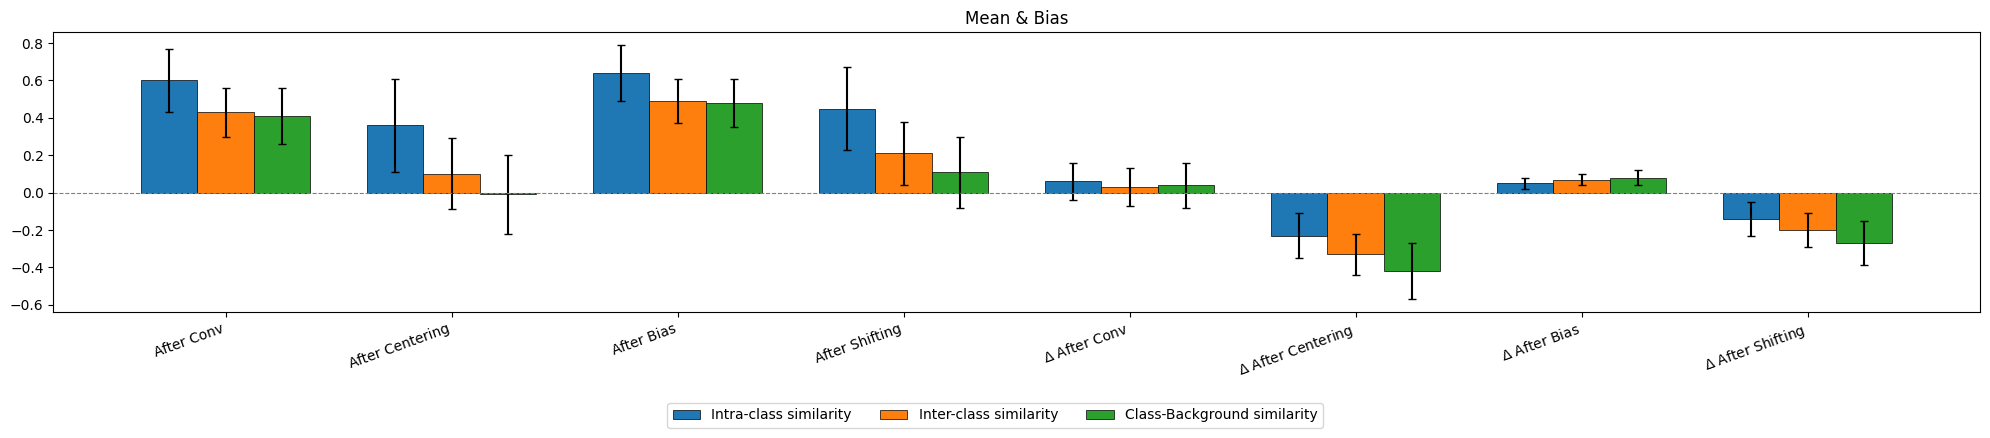

In [6]:
s = """
| YOLO | After Conv | After Centering | After Bias | After Shifting | $\Delta$ After Conv | $\Delta$ After Centering | $\Delta$ After Bias | $\Delta$ After Shifting |
| -- | -- | -- | -- | -- | -- | -- | -- | -- |
| Mean & Bias | in 0.60±0.17<br>out 0.43±0.13<br>back 0.41±0.15<br> | in 0.36±0.25<br>out 0.10±0.19<br>back -0.01±0.21<br> | in 0.64±0.15<br>out 0.49±0.12<br>back 0.48±0.13<br> | in 0.45±0.22<br>out 0.21±0.17<br>back 0.11±0.19<br> | in 0.06±0.10<br>out 0.03±0.10<br>back 0.04±0.12<br> | in -0.23±0.12<br>out -0.33±0.11<br>back -0.42±0.15<br> | in 0.05±0.03<br>out 0.07±0.03<br>back 0.08±0.04<br> | in -0.14±0.09<br>out -0.20±0.09<br>back -0.27±0.12<br> | 
"""
data, domain_name = parse_table(s)
plot_models(data, domain_name)

## Figure 6 Sound

In [1]:
# to reproduce table for Audio
# run code in "Figure 6 Preparation" section
# in sound/plots_sound.ipynb

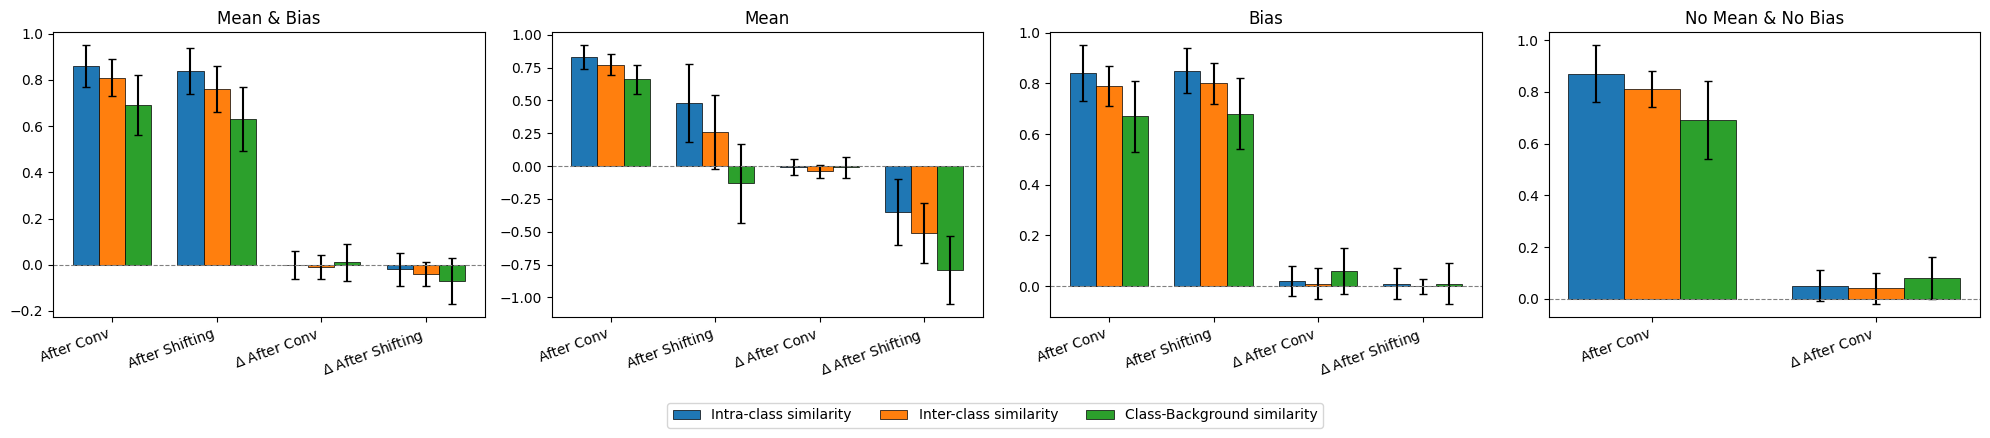

In [ ]:
s = """
| Audio | After Conv | After Shifting | $\Delta$ After Conv | $\Delta$ After Shifting |
| --- | --- | --- | --- | --- |
| Mean & Bias | in 0.86±0.09<br>out 0.81±0.08<br>back 0.69±0.13 | in 0.84±0.1<br>out 0.76±0.1<br>back 0.63±0.14 | in 0.0±0.06<br>out -0.01±0.05<br>back 0.01±0.08 | in -0.02±0.07<br>out -0.04±0.05<br>back -0.07±0.1 |
| Mean | in 0.83±0.09<br>out 0.77±0.08<br>back 0.66±0.11 | in 0.48±0.3<br>out 0.26±0.28<br>back -0.13±0.3 | in -0.01±0.06<br>out -0.04±0.05<br>back -0.01±0.08 | in -0.35±0.25<br>out -0.51±0.23<br>back -0.79±0.26 |
| Bias | in 0.84±0.11<br>out 0.79±0.08<br>back 0.67±0.14 | in 0.85±0.09<br>out 0.8±0.08<br>back 0.68±0.14 | in 0.02±0.06<br>out 0.01±0.06<br>back 0.06±0.09 | in 0.01±0.06<br>out 0.0±0.03<br>back 0.01±0.08 |
| No Mean & No Bias | in 0.87±0.11<br>out 0.81±0.07<br>back 0.69±0.15 |  | in 0.05±0.06<br>out 0.04±0.06<br>back 0.08±0.08 |  |
"""
data, domain_name = parse_table(s)
plot_models(data, domain_name)

## Figure 6 Facerec

In [ ]:
# to reproduce table for FaceRec
# run code in "Figure 6 Preparation" section
# in facerec_and_cifar/plots_arcface.ipynb

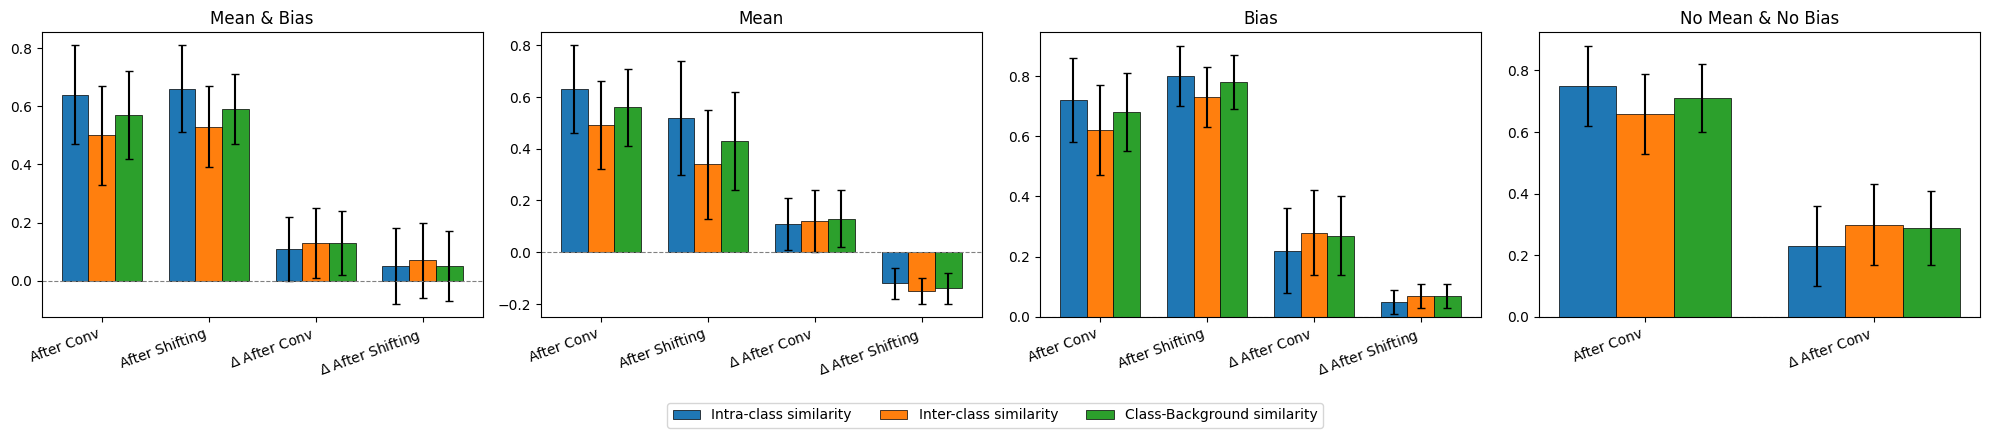

In [ ]:
s = """
| FaceRec | After Conv | After Shifting | $\Delta$ After Conv | $\Delta$ After Shifting |
| -- | -- | -- | -- | -- |
| Mean & Bias | in 0.64±0.17<br>out 0.50±0.17<br>back 0.57±0.15<br> | in 0.66±0.15<br>out 0.53±0.14<br>back 0.59±0.12<br> | in 0.11±0.11<br>out 0.13±0.12<br>back 0.13±0.11<br> | in 0.05±0.13<br>out 0.07±0.13<br>back 0.05±0.12<br> |
| Mean | in 0.63±0.17<br>out 0.49±0.17<br>back 0.56±0.15<br> | in 0.52±0.22<br>out 0.34±0.21<br>back 0.43±0.19<br> | in 0.11±0.10<br>out 0.12±0.12<br>back 0.13±0.11<br> | in -0.12±0.06<br>out -0.15±0.05<br>back -0.14±0.06<br> | 
| Bias | in 0.72±0.14<br>out 0.62±0.15<br>back 0.68±0.13<br> | in 0.80±0.10<br>out 0.73±0.10<br>back 0.78±0.09<br> | in 0.22±0.14<br>out 0.28±0.14<br>back 0.27±0.13<br> | in 0.05±0.04<br>out 0.07±0.04<br>back 0.07±0.04<br> | 
| No Mean & No Bias | in 0.75±0.13<br>out 0.66±0.13<br>back 0.71±0.11<br> | | in 0.23±0.13<br>out 0.30±0.13<br>back 0.29±0.12<br> | | 
"""
data, domain_name = parse_table(s)
plot_models(data, domain_name)

## Figure 6 Cifar

In [ ]:
# to reproduce table for Cifar100
# run code in "Figure 6 Preparation" section
# in facerec_and_cifar/plots_cifar100.ipynb

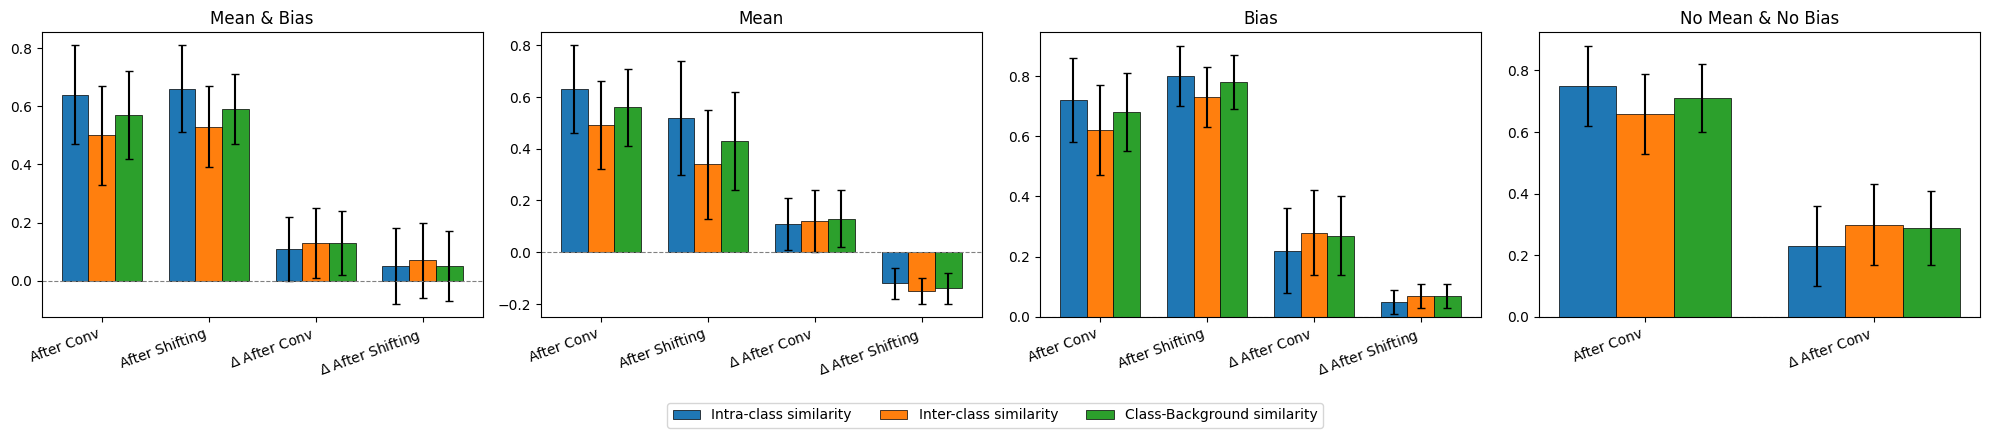

In [ ]:
s = """
| CIFAR100 | After Conv | After Shifting | $\Delta$ After Conv | $\Delta$ After Shifting |
| -- | -- | -- | -- | -- |
| Mean & Bias | in 0.47±0.19<br>out 0.41±0.17<br>back 0.45±0.17<br> | in 0.20±0.27<br>out 0.11±0.24<br>back 0.15±0.24<br> | in 0.07±0.13<br>out 0.07±0.13<br>back 0.07±0.12<br> | in -0.27±0.13<br>out -0.31±0.13<br>back -0.31±0.14<br> | 
| Mean | in 0.46±0.19<br>out 0.40±0.17<br>back 0.45±0.16<br> | in 0.19±0.27<br>out 0.10±0.24<br>back 0.15±0.24<br> | in 0.06±0.13<br>out 0.06±0.13<br>back 0.06±0.12<br> | in -0.27±0.14<br>out -0.31±0.13<br>back -0.31±0.16<br> | 
| Bias | in 0.44±0.23<br>out 0.37±0.21<br>back 0.41±0.21<br> | in 0.44±0.23<br>out 0.38±0.21<br>back 0.42±0.20<br> | in 0.07±0.17<br>out 0.08±0.16<br>back 0.08±0.15<br> | in 0.00±0.01<br>out 0.00±0.01<br>back 0.01±0.02<br> | 
| No Mean & No Bias | in 0.44±0.25<br>out 0.37±0.23<br>back 0.39±0.22<br> | | in 0.07±0.19<br>out 0.07±0.18<br>back 0.07±0.18<br> | |
"""
data, domain_name = parse_table(s)
plot_models(data, domain_name)

# Figure 8

In [1]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

In [ ]:
# to reproduce dict for YOLO
# run code in "Figure 8 Preparation" section
# in yolo/plots_yolo.ipynb

In [ ]:
# to reproduce dict for Audio
# run code in "Figure 8 Preparation" section
# in sound/plots_sound.ipynb

In [ ]:
# to reproduce dict for FaceRec
# run code in "Figure 8 Preparation" section
# in facerec_and_cifar/plots_arcface.ipynb

In [ ]:
# to reproduce dict for Cifar100
# run code in "Figure 8 Preparation" section
# in facerec_and_cifar/plots_cifar100.ipynb

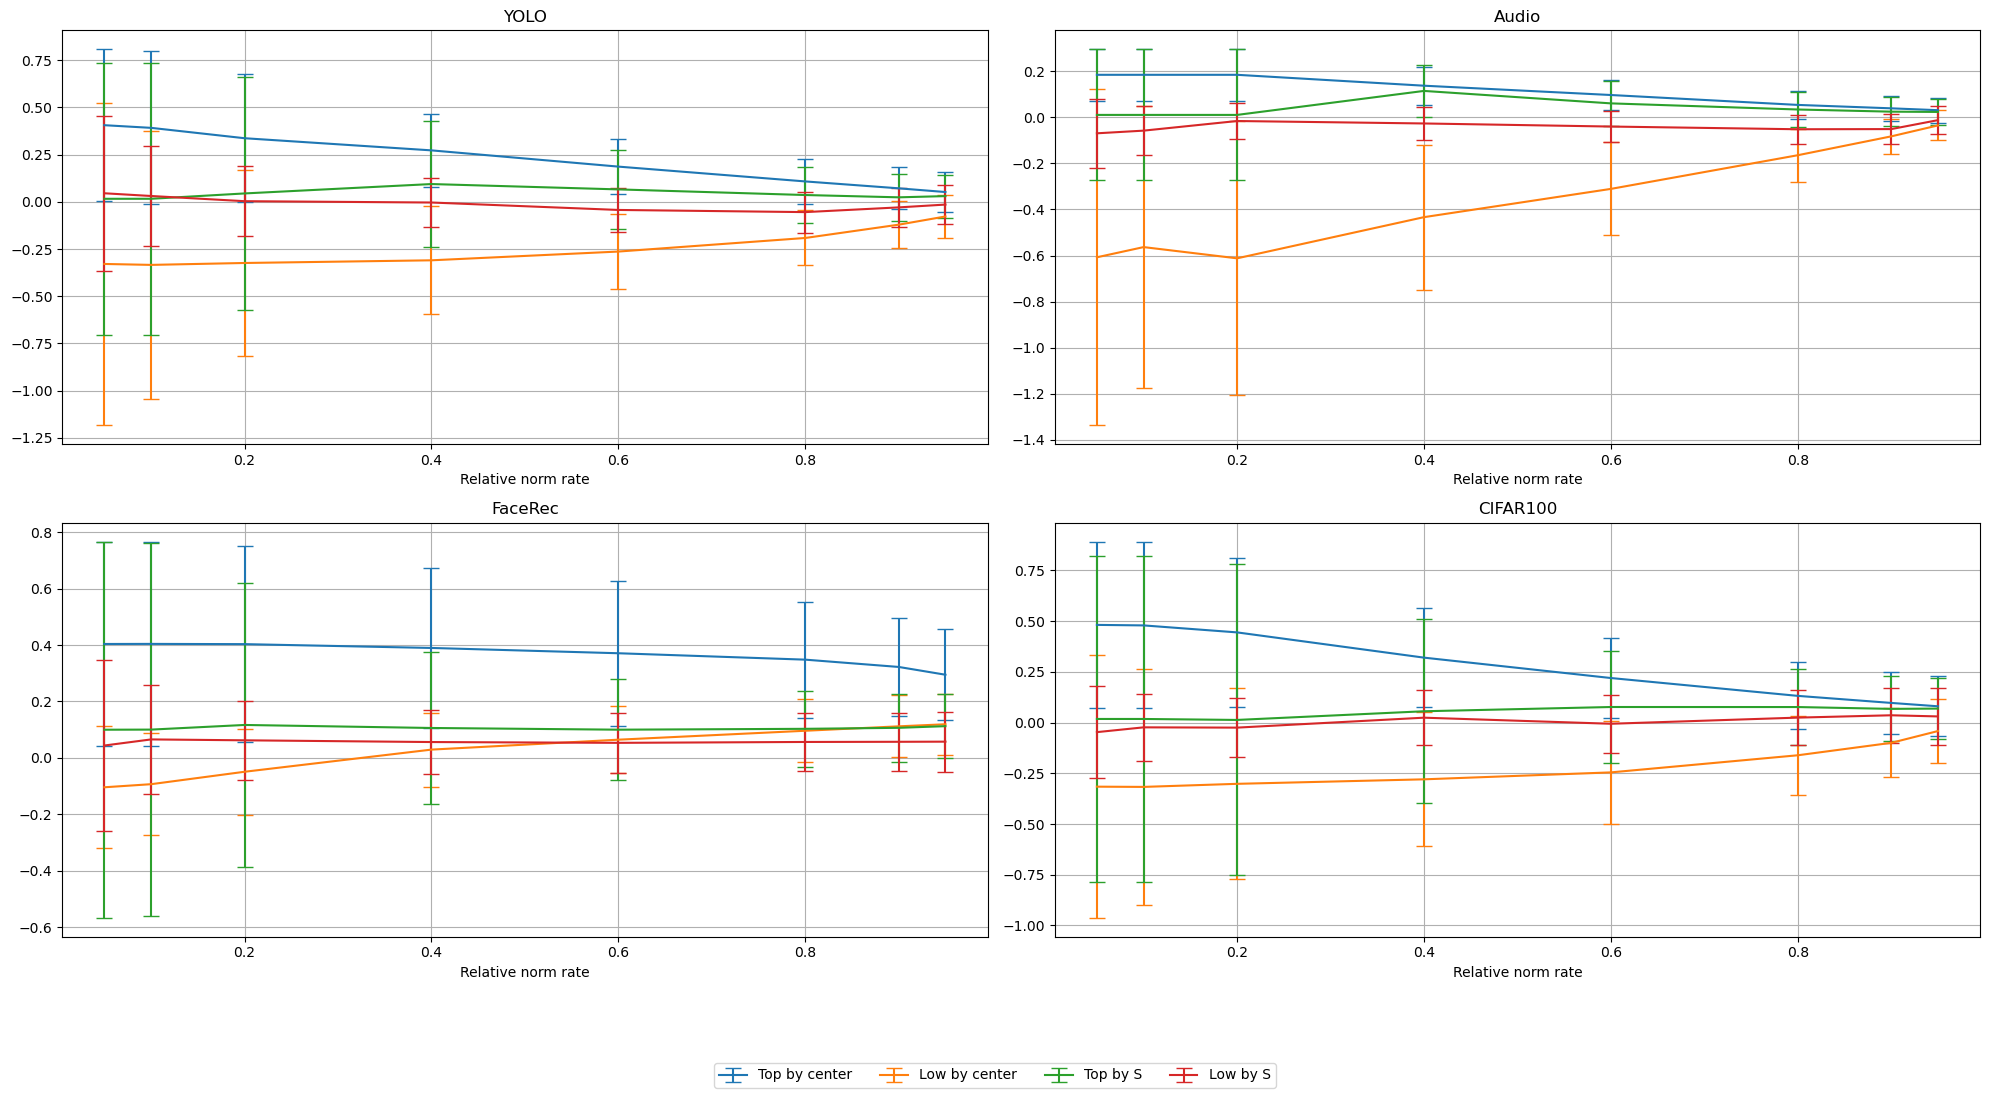

In [2]:
VS = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95]

RES_YOLO = {
    'Top by center': ([0.40621, 0.39214, 0.3372, 0.27281, 0.18677, 0.10826, 0.07174, 0.05206],
                      [0.40329, 0.40472, 0.33869, 0.19207, 0.14393, 0.11957, 0.11052, 0.10679]),
    'Low by center': ([-0.32908, -0.33401, -0.32389, -0.30971, -0.26333, -0.19137, -0.12089, -0.07747],
                      [0.85521, 0.70842, 0.49336, 0.28646, 0.19767, 0.14574, 0.12283, 0.11536]),
    'Top by S': ([0.01622, 0.01632, 0.04461, 0.09435, 0.06601, 0.03621, 0.02403, 0.03046],
                 [0.72097, 0.7209, 0.61895, 0.33542, 0.21087, 0.14632, 0.12561, 0.11417]),
    'Low by S': ([0.04548, 0.03106, 0.00358, -0.00349, -0.04288, -0.05433, -0.0293, -0.01438],
                 [0.41136, 0.26334, 0.18428, 0.12783, 0.11555, 0.10807, 0.10448, 0.10471])
}

RES_AUDIO = {
    'Top by center': ([0.18543194, 0.18543194, 0.18543194, 0.13808453, 0.09761933, 0.054583352, 0.039728634, 0.031650014],
                      [0.11176596, 0.11176596, 0.11176596, 0.08237587, 0.06641048, 0.060551025, 0.055488147, 0.05403908]),
    'Low by center': ([-0.6077074, -0.5634159, -0.61223304, -0.43328515, -0.31045803, -0.16409732, -0.08213921, -0.034604244],
                      [0.7304956, 0.61255944, 0.5950019, 0.31494376, 0.20194456, 0.11609868, 0.074965954, 0.06541778]),
    'Top by S': ([0.011116591, 0.011116591, 0.011116591, 0.115393296, 0.06125624, 0.034646206, 0.025233993, 0.024044113],
                 [0.28462228, 0.28462228, 0.28462228, 0.11368598, 0.09670543, 0.07691584, 0.06287193, 0.057640295]),
    'Low by S': ([-0.06884582, -0.05724598, -0.015398368, -0.02607134, -0.03945989, -0.051232606, -0.050513495, -0.011615011],
                 [0.15086462, 0.107000425, 0.077649705, 0.06983437, 0.0690344, 0.06362675, 0.06466792, 0.059313215]),
}

RES_FACEREC = {
    'Top by center': ([0.40362, 0.40392, 0.40309, 0.38954, 0.3708, 0.34811, 0.32226, 0.2947],
                      [0.36068, 0.36193, 0.34806, 0.28303, 0.25749, 0.2058, 0.17285, 0.16196]),
    'Low by center': ([-0.10403, -0.09308, -0.04906, 0.02943, 0.06456, 0.0962, 0.11188, 0.11923],
                      [0.21624, 0.18024, 0.15325, 0.13073, 0.11947, 0.11237, 0.10991, 0.10895]),
    'Top by S': ([0.09987, 0.1003, 0.11674, 0.10604, 0.10001, 0.10305, 0.10662, 0.11251],
                 [0.66649, 0.66064, 0.50461, 0.26816, 0.1793, 0.13459, 0.12073, 0.1144]),
    'Low by S': ([0.04393, 0.06552, 0.06235, 0.05621, 0.05338, 0.05652, 0.05711, 0.05758],
                 [0.30267, 0.1944, 0.14034, 0.11407, 0.10616, 0.104, 0.1026, 0.1062])
}

RES_CIFAR100 = {
    'Top by center': ([0.4813, 0.47876, 0.44434, 0.31993, 0.21942, 0.13146, 0.09669, 0.08009],
                      [0.4106, 0.40907, 0.36634, 0.24474, 0.19507, 0.16467, 0.15386, 0.14776]),
    'Low by center': ([-0.31612, -0.31725, -0.30211, -0.27992, -0.24571, -0.16134, -0.10012, -0.04195],
                      [0.64659, 0.58342, 0.47066, 0.33042, 0.25255, 0.19545, 0.17068, 0.15765]),
    'Top by S': ([0.01762, 0.01761, 0.01282, 0.05561, 0.07656, 0.07636, 0.06735, 0.06875],
                 [0.80136, 0.80137, 0.76637, 0.45391, 0.27639, 0.18851, 0.16001, 0.14978]),
    'Low by S': ([-0.04728, -0.0237, -0.02507, 0.02394, -0.00598, 0.02425, 0.03579, 0.03014],
                 [0.22617, 0.16663, 0.14508, 0.13446, 0.14277, 0.13702, 0.13564, 0.14172])
}


pdf = PdfPages('heap/while_truncated_conv.pdf')
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()

for ax, (RES, data_name) in zip(axes, [
    (RES_YOLO, 'YOLO'),
    (RES_AUDIO, 'Audio'),
    (RES_FACEREC, 'FaceRec'),
    (RES_CIFAR100, 'CIFAR100'),
]):
    for k, (m, s) in RES.items():
        ax.errorbar(VS, m, s, label=k, capsize=6)
    
    ax.grid()
    ax.set_title(data_name)
    ax.set_xlabel('Relative norm rate')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles=handles, labels=labels, ncol=len(labels), loc='lower center', 
            bbox_to_anchor=(0.5, -0.1)
            )

plt.tight_layout()
pdf.savefig(bbox_inches='tight')
pdf.close()
plt.show()